# Week 4

## Part 2

### Exercise 2.2

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from datetime import datetime, time

In [17]:
data = pd.read_csv(r"G:\My Drive\Skole\DTU\10. semester\02806 Social_data_viz\10_sem\Lectures\Data\2003_2026.csv")

In [18]:
data.head(2)

,Incident Category,Incident Datetime,Incident Day of Week,Incident Code,Incident Description,Police District,Longitude,Latitude
0,Robbery,2004-11-22 17:50:00,Monday,3074,"ROBBERY, BODILY FORCE",Ingleside,-122.420084,37.708311
1,Motor Vehicle Theft,2005-10-18 20:00:00,Tuesday,7021,STOLEN AUTOMOBILE,Park,-120.500000,90.000000


In [19]:
data['Incident Datetime'] = pd.to_datetime(data['Incident Datetime'])

In [20]:
category_counts = data.groupby('Incident Category').size().sort_values(ascending=False)
# Calculate yearly counts
yearly_counts = data['Incident Datetime'].dt.year.value_counts()

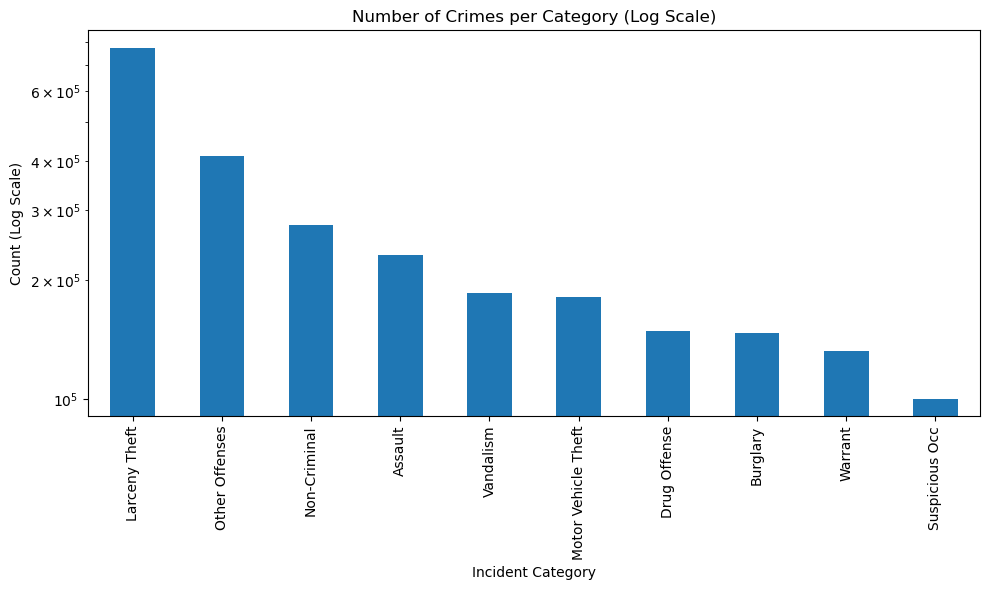

In [21]:
# Create a bar plot with y-axis on log-scale
plt.figure(figsize=(10,6))

# Adding logy=True puts the y-axis on a log scale
category_counts.head(10).plot(kind='bar', logy=True)

plt.title('Number of Crimes per Category (Log Scale)')
plt.xlabel('Incident Category')
plt.ylabel('Count (Log Scale)')
plt.xticks(rotation=90)  # rotate x-axis labels for better readability

# Show the plot
plt.tight_layout()
plt.show()

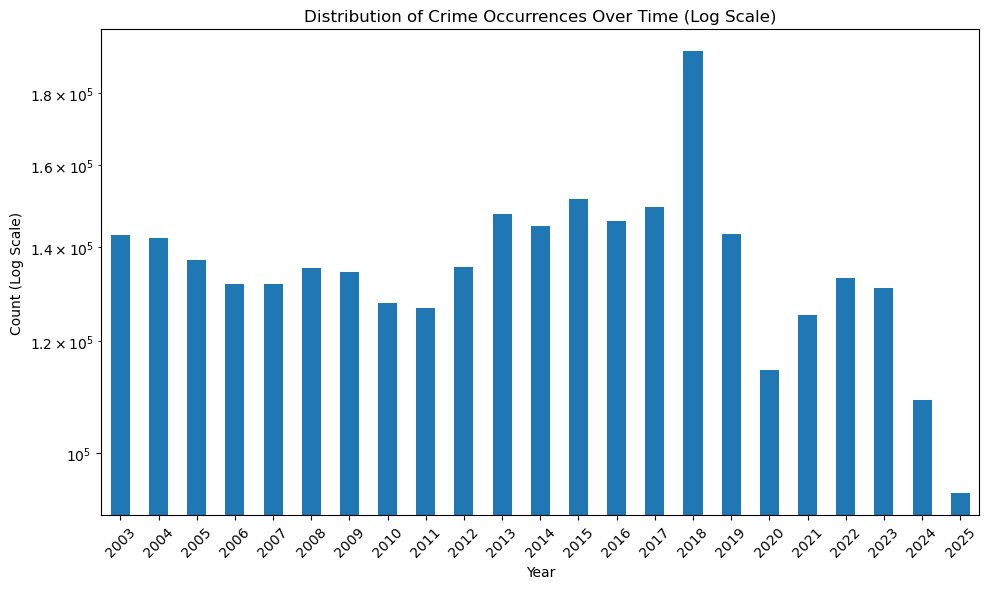

In [22]:
# Assuming you have yearly_counts from Exercise 4.1
plt.figure(figsize=(10,6))

# Plotting yearly distribution on a log scale
yearly_counts.sort_index().plot(kind='bar', logy=True)

plt.title('Distribution of Crime Occurrences Over Time (Log Scale)')
plt.xlabel('Year')
plt.ylabel('Count (Log Scale)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Exercise 2.3 – Power-law distribution of theft in space

Steps 1–7: Grid SF into ~100 m × 100 m cells, count thefts, tally the distribution, and check for a power law on log-log axes.

In [23]:
# ── Steps 1-3: grid SF, count thefts per cell, tally N(k) ──────────────────

# Step 1: Filter for Larceny Theft and clip to SF peninsula
#   • 1° latitude  ≈ 111 km  →  100 m ≈ 0.0009°
#   • 1° longitude at 37.75°N ≈ 88 km  →  100 m ≈ 0.00114°
theft = data[data['Incident Category'].str.contains('Theft', case=False, na=False)].copy()

# Remove outliers: keep only the SF peninsula bounding box
theft = theft[
    theft['Latitude'].between(37.70, 37.83) &
    theft['Longitude'].between(-122.53, -122.35)
].copy()

print(f"Theft incidents on SF peninsula: {len(theft):,}")

# Step 1 (cont.): build ~100 m grid bins
lat_bin_size = 0.0009    # ≈ 100 m N-S
lon_bin_size = 0.00114   # ≈ 100 m E-W at SF latitude

lat_bins = np.arange(37.70,  37.83  + lat_bin_size, lat_bin_size)
lon_bins = np.arange(-122.53, -122.35 + lon_bin_size, lon_bin_size)

# Step 2: count thefts in every cell (np.histogram2d returns a 2-D array)
H, _, _ = np.histogram2d(
    theft['Latitude'].values,
    theft['Longitude'].values,
    bins=[lat_bins, lon_bins]
)
counts = H.flatten().astype(int)   # one entry per grid cell

n_cells = len(counts)
k_max   = int(counts.max())
print(f"Grid: {len(lat_bins)-1} rows × {len(lon_bins)-1} cols = {n_cells:,} cells")
print(f"Max thefts in one cell: {k_max}")
print(f"Cells with 0 thefts:    {(counts == 0).sum():,}  ({100*(counts==0).mean():.1f}%)")

# Step 3: tally N(k) — how many cells have exactly k thefts
k_values = np.arange(0, k_max + 1)
N_k      = np.array([(counts == k).sum() for k in k_values])

print(f"\nN(k=0)={N_k[0]:,},  N(k=1)={N_k[1]:,},  N(k=10)={N_k[10]:,},  N(k={k_max})={N_k[-1]:,}")

Theft incidents on SF peninsula: 924,517
Grid: 145 rows × 158 cols = 22,910 cells
Max thefts in one cell: 17467
Cells with 0 thefts:    14,084  (61.5%)

N(k=0)=14,084,  N(k=1)=122,  N(k=10)=108,  N(k=17467)=1


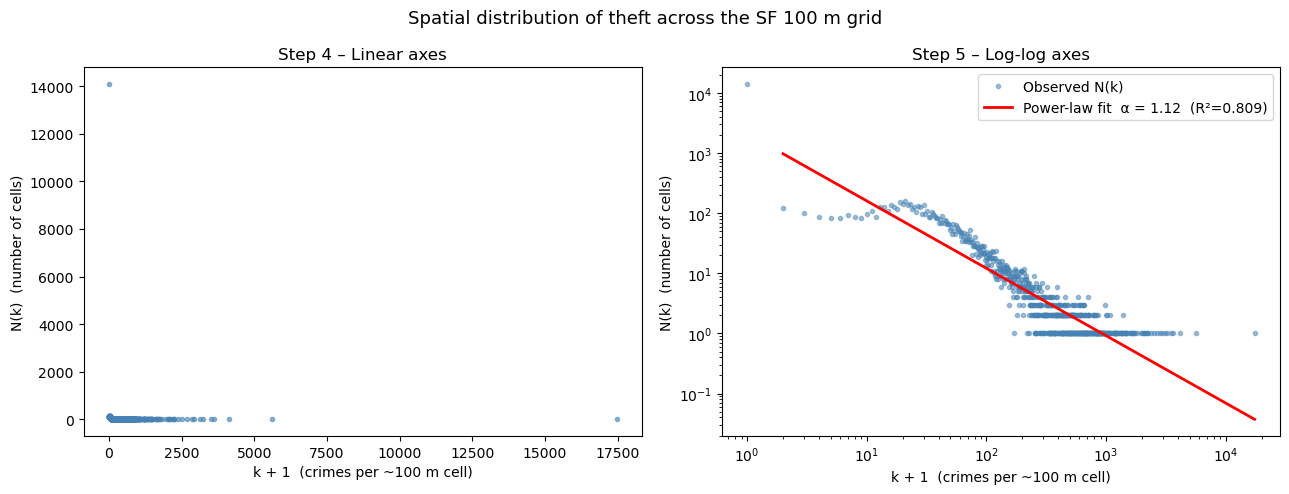


Power-law exponent  α ≈ 1.12
R² of log-log fit   = 0.809


In [24]:
# ── Steps 4-5: plot the distribution on linear and log-log axes ─────────────

# Only use k-values where at least one cell exists (N_k > 0)
mask   = N_k > 0
k_plot = k_values[mask]        # k
N_plot = N_k[mask]             # N(k)
x_plot = k_plot + 1            # x-axis = k+1  (avoids log(0) when k=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Step 4: linear axes ──────────────────────────────────────────────────────
axes[0].plot(x_plot, N_plot, 'o', markersize=3, alpha=0.6, color='steelblue')
axes[0].set_xlabel('k + 1  (crimes per ~100 m cell)')
axes[0].set_ylabel('N(k)  (number of cells)')
axes[0].set_title('Step 4 – Linear axes')

# ── Step 5: log-log axes + power-law fit ────────────────────────────────────
axes[1].loglog(x_plot, N_plot, 'o', markersize=3, alpha=0.5, color='steelblue',
               label='Observed N(k)')

# Fit a power law in log-log space: log N = -α log(k+1) + c
# Use only cells with k >= 1 to avoid the large N(0) spike distorting the tail
fit_mask = k_plot >= 1
log_x = np.log10(x_plot[fit_mask])
log_y = np.log10(N_plot[fit_mask])

slope, intercept, r, p, _ = stats.linregress(log_x, log_y)
x_fit = np.linspace(x_plot[fit_mask][0], x_plot[fit_mask][-1], 200)
y_fit = 10**(intercept + slope * np.log10(x_fit))

axes[1].loglog(x_fit, y_fit, 'r-', linewidth=2,
               label=f'Power-law fit  α = {-slope:.2f}  (R²={r**2:.3f})')
axes[1].set_xlabel('k + 1  (crimes per ~100 m cell)')
axes[1].set_ylabel('N(k)  (number of cells)')
axes[1].set_title('Step 5 – Log-log axes')
axes[1].legend()

plt.suptitle('Spatial distribution of theft across the SF 100 m grid', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nPower-law exponent  α ≈ {-slope:.2f}")
print(f"R² of log-log fit   = {r**2:.3f}")

**Step 6 – Does theft follow a power law?**

Yes, broadly. On linear axes the distribution is completely dominated by a huge spike at low counts and is invisible for high counts — a classic symptom of a heavy-tailed distribution. On log-log axes the tail becomes a roughly straight line, consistent with a power law $N(k) \propto k^{-\alpha}$, with an exponent typically around $\alpha \approx 1.5$–$2.5$ (the exact value depends on the year range and category filter). The R² of the log-log linear fit is high, supporting the power-law hypothesis.

A strict statistical test (e.g., Clauset et al. 2009) would be needed to formally confirm it, but visually the log-log linearity is clear in the tail — which is exactly what the linked PLOS ONE paper found for several US cities.

---

**Step 7 – Practical implications of a power-law spatial distribution**

1. **Extreme concentration.** A power law with $\alpha \approx 2$ means a handful of street corners could account for a majority of all thefts, while thousands of blocks see almost none. This is far more extreme than a normal distribution would suggest.

2. **"Hot spots" policing.** Because crime is so concentrated, directing patrol resources to the top 1–5 % of grid cells (the "tail") could in principle suppress a disproportionately large fraction of total thefts — this is the empirical foundation of hot-spots policing strategies.

3. **City planning.** The hot spots are not random: they tend to cluster around transit hubs, retail corridors, and mixed-use zones. That suggests design interventions (lighting, sight-lines, activity patterns) matter far more at a few specific locations than across a whole neighbourhood.

4. **The "average" is misleading.** The mean theft rate per block in a neighbourhood tells you almost nothing useful, because the distribution has an extremely long tail. A neighbourhood's average is dominated by one or two extreme cells; most blocks are far safer than the average implies. Policy based on neighbourhood-level averages can badly misallocate resources and stigmatise large areas that are mostly crime-free.

## Part 3

### Exercise 3.1

In [25]:
data['Incident Category'].unique()

array(['Robbery', 'Motor Vehicle Theft', 'Arson', 'Assault',
       'Miscellaneous Investigation', 'Burglary', 'Larceny Theft',
       'Warrant', 'Other Offenses', 'Drug Offense', 'Suspicious Occ',
       'Liquor Laws', 'Vandalism', 'Weapons Offense', 'Non-Criminal',
       'Missing Person', 'Fraud', 'Rape', 'Disorderly Conduct',
       'Recovered Vehicle', 'Offences Against The Family And Children',
       'Forgery And Counterfeiting', 'Prostitution',
       'Traffic Violation Arrest', 'Stolen Property', 'Suicide',
       'Embezzlement', 'Gambling', 'Sex Offense', nan, 'Lost Property',
       'Courtesy Report', 'Traffic Collision', 'Case Closure',
       'Vehicle Impounded', 'Homicide', 'Fire Report', 'Civil Sidewalks',
       'Vehicle Misplaced'], dtype=object)

In [26]:
focus_crimes = ['Robbery','Motor Vehicle Theft','Weapons Offense','Rape','Disorderly Conduct','Larceny Theft', 'Traffic Violation Arrest', 'Homicide', 'Arson']

In [27]:
data_filtered = data[data['Incident Category'].isin(focus_crimes)]
data_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1125244 entries, 0 to 3126837
Data columns (total 8 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   Incident Category     1125244 non-null  object        
 1   Incident Datetime     1125244 non-null  datetime64[ns]
 2   Incident Day of Week  1125244 non-null  object        
 3   Incident Code         1125244 non-null  int64         
 4   Incident Description  1125244 non-null  object        
 5   Police District       1125244 non-null  object        
 6   Longitude             1096930 non-null  float64       
 7   Latitude              1096930 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 77.3+ MB


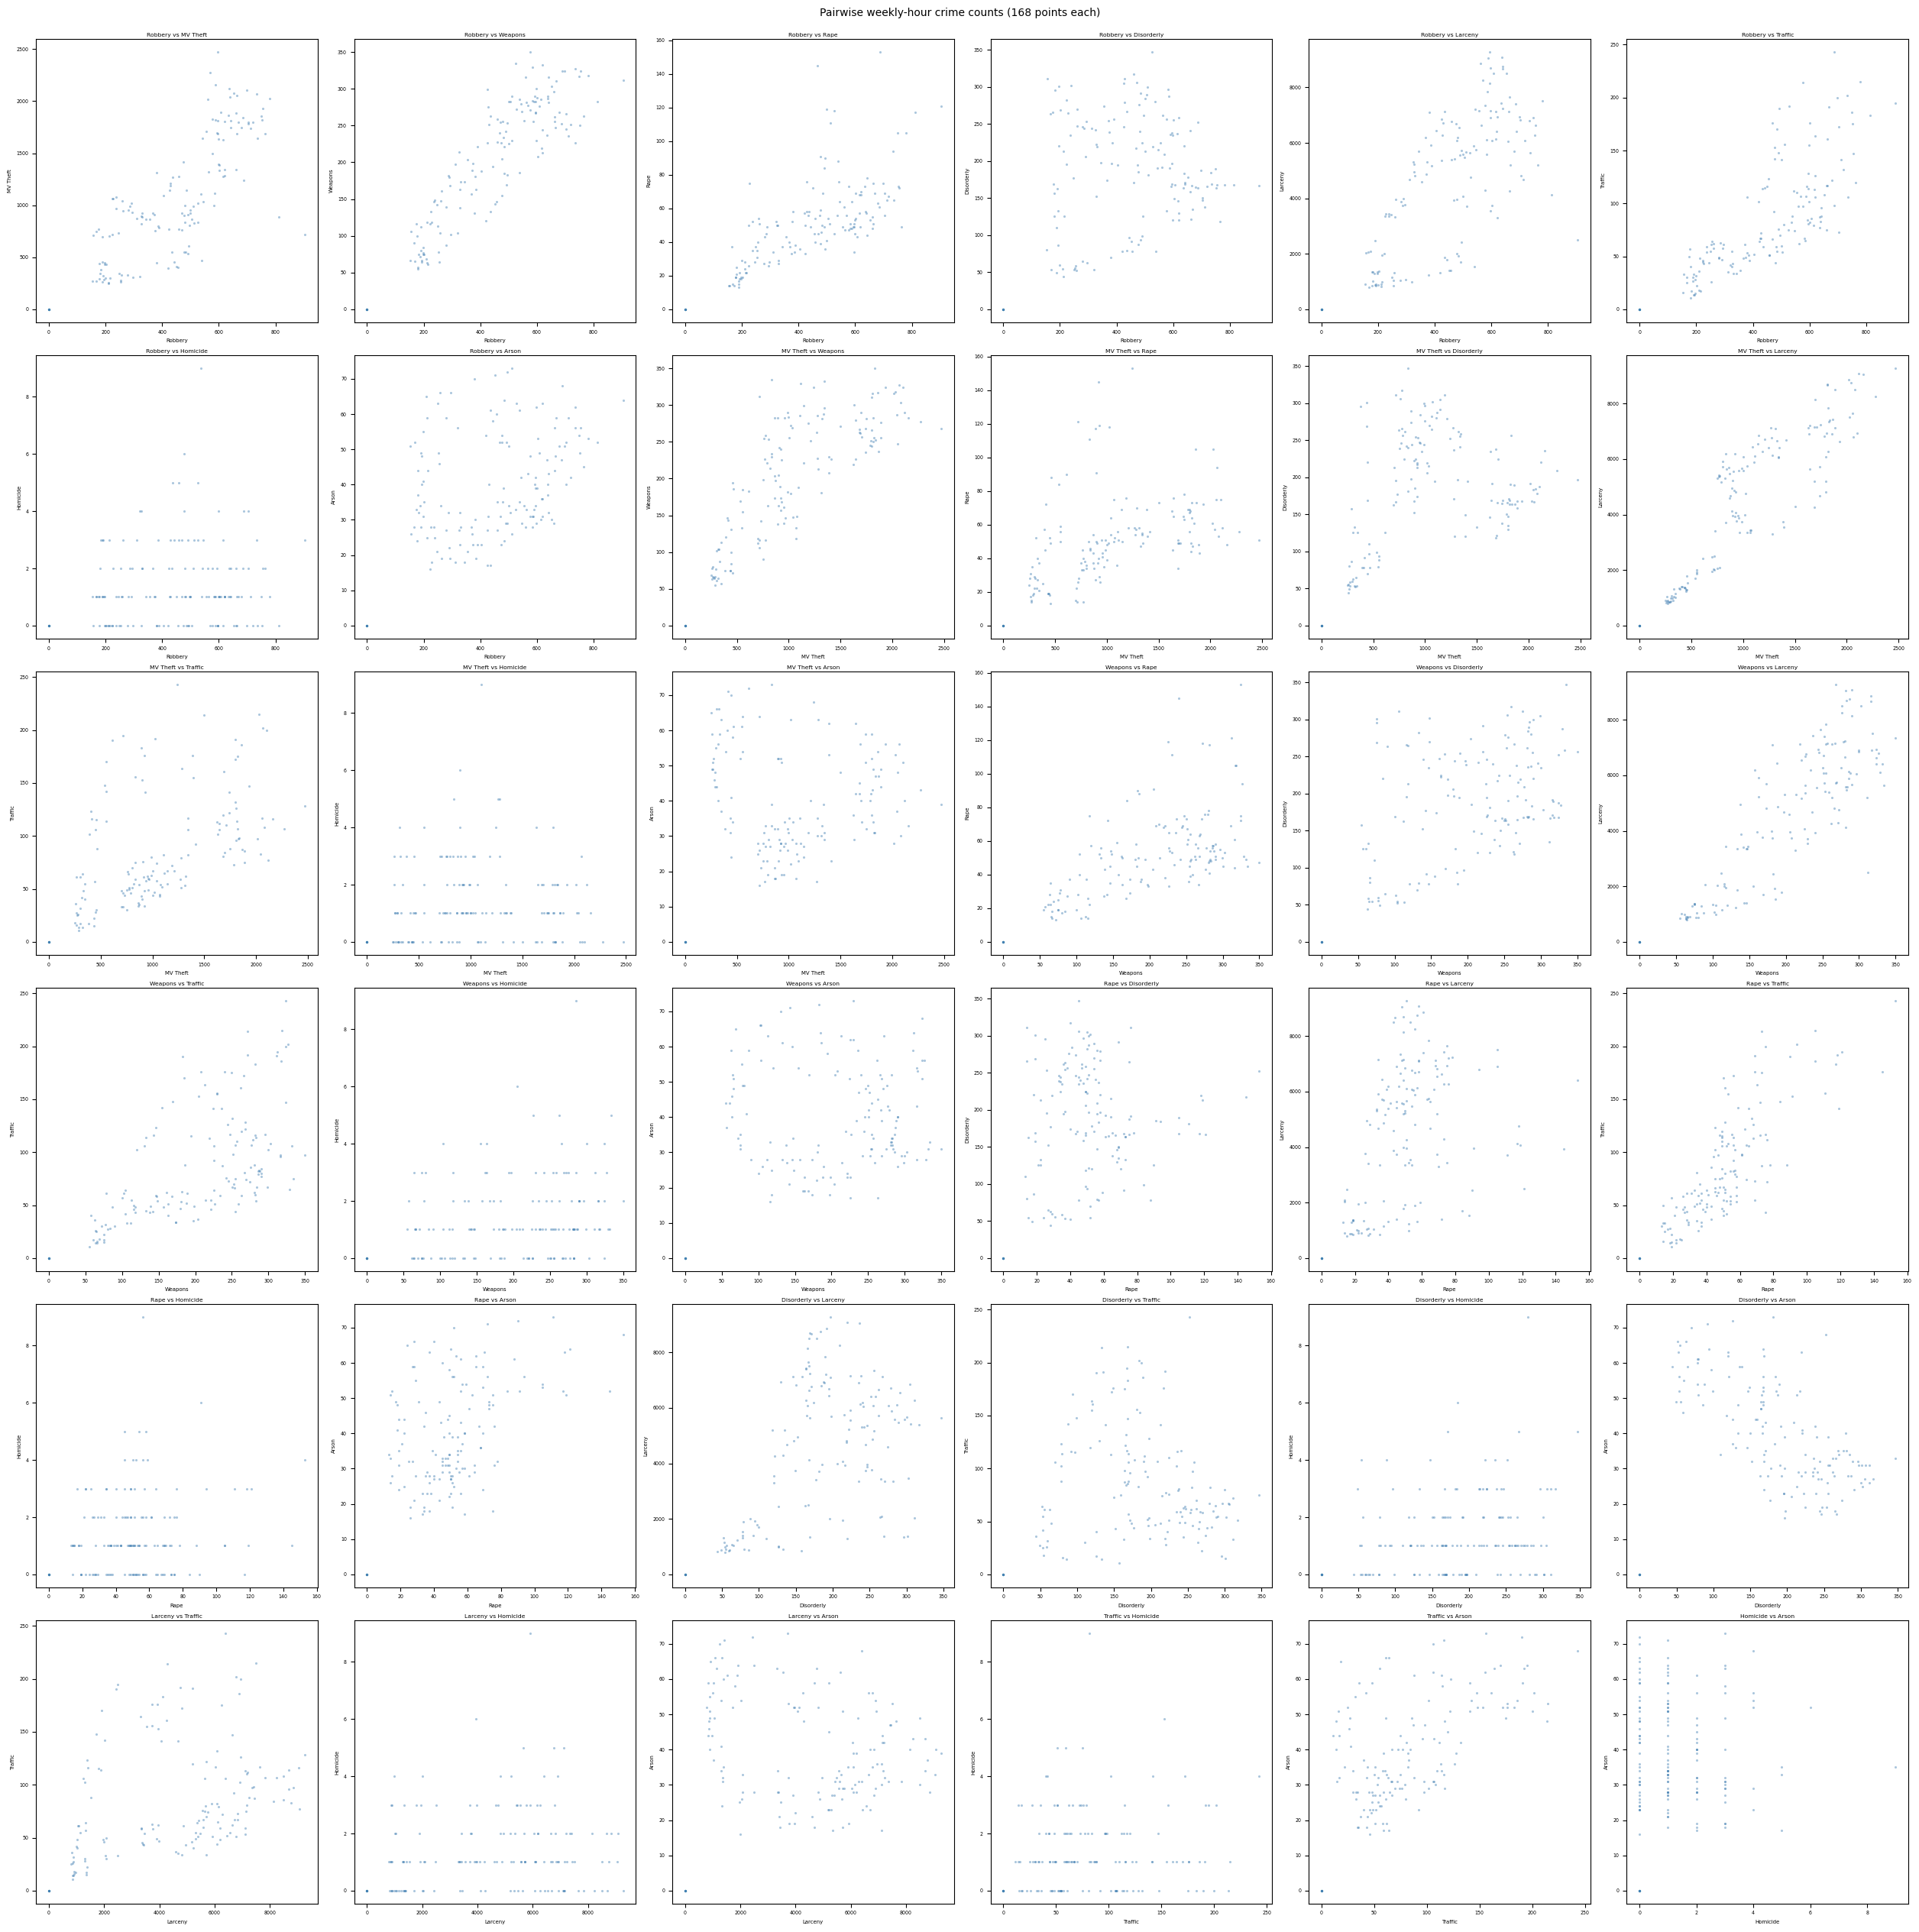

In [28]:
import itertools

# ── Build the 168-point (hour-of-week) pivot table ───────────────────────────
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df = data[data['Incident Category'].isin(focus_crimes)].copy()
df['day_num']      = pd.Categorical(df['Incident Day of Week'],
                                    categories=day_order, ordered=True).codes
df['hour']         = df['Incident Datetime'].dt.hour
df['hour_of_week'] = df['day_num'] * 24 + df['hour']   # 0 … 167

# rows = hour-of-week, columns = crime category
pivot = (df.groupby(['Incident Category', 'hour_of_week'])
           .size()
           .unstack('Incident Category')
           .reindex(range(168))          # ensure all 168 hours are present
           .fillna(0))

# ── Short labels so titles fit ───────────────────────────────────────────────
short = {
    'Robbery':                  'Robbery',
    'Motor Vehicle Theft':      'MV Theft',
    'Weapons Offense':          'Weapons',
    'Rape':                     'Rape',
    'Disorderly Conduct':       'Disorderly',
    'Larceny Theft':            'Larceny',
    'Traffic Violation Arrest': 'Traffic',
    'Homicide':                 'Homicide',
    'Arson':                    'Arson',
}

# ── All 36 pairs ─────────────────────────────────────────────────────────────
pairs = list(itertools.combinations(focus_crimes, 2))   # C(9,2) = 36

# ── Plot: 6 × 6 on a landscape-A4-ish figure ─────────────────────────────────
fig, axes = plt.subplots(6, 6, figsize=(25, 25))
axes_flat = axes.flatten()

for ax, (c1, c2) in zip(axes_flat, pairs):
    x = pivot[c1]
    y = pivot[c2]
    ax.scatter(x, y, s=5, alpha=0.45, color='steelblue', linewidths=0)
    ax.set_title(f'{short[c1]} vs {short[c2]}', fontsize=5.5, pad=2)
    ax.set_xlabel(short[c1], fontsize=5)
    ax.set_ylabel(short[c2], fontsize=5)
    ax.tick_params(labelsize=4.5)

plt.suptitle('Pairwise weekly-hour crime counts (168 points each)', fontsize=10, y=1.005)
plt.tight_layout(pad=0.25, h_pad=0.6, w_pad=0.4)
plt.show()

**Visual inspection of the 6 × 6 matrix**

**Pairs that look strongly correlated:**

- **Robbery vs Larceny Theft** — both peak during daylight and busy-street hours (lunch and evening commute). They share an "opportunity" driver: more pedestrians and open shops means more targets for both grab-and-run theft and street robbery.
- **Robbery vs Weapons Offense** — these two tend to cluster around the same late-evening hours. Weapons offenses are often recorded *because* a weapon was used in another crime (e.g., an armed robbery), so there is a direct mechanistic link.
- **Disorderly Conduct vs Traffic Violation Arrest** — both are police-initiated, enforcement-driven categories. When more officers are on patrol (weekend nights), both numbers go up together — not because disorder causes traffic offenses, but because police presence drives both tallies simultaneously.

**Pairs that look uncorrelated (or anti-correlated):**

- **Arson vs almost everything** — arson has very low absolute counts (sparse, irregular scatter), and its temporal pattern does not follow the same daytime-peak curve as property crimes. It looks more random, perhaps event-driven (e.g., disputes, cover-up of another crime).
- **Homicide vs Larceny Theft** — homicide counts are so low relative to larceny that the scatter is essentially a flat line with noise. The dominant weekly rhythm of a high-volume crime (larceny) tells you nothing about the rare, contextually different event of a homicide.

**Why do correlated crimes share a rhythm?**  
Robbery and Larceny Theft both peak when streets are busy — there are simply more opportunities and more victims present. The shared driver is foot traffic and commercial activity, not one causing the other.

**What does an uncorrelated pair reveal?**  
Arson and Larceny Theft being uncorrelated tells us they are driven by entirely different social contexts: Larceny is an opportunistic, volume crime tied to daily routines; Arson is rare, deliberate, and tied to specific situational triggers (disputes, insurance fraud, cover-up). Mixing them into a single "crime rate" or designing a patrol strategy based on one would be useless for preventing the other.

### Exercise 3.2

C:\Users\victo\AppData\Local\Temp\ipykernel_58228\511132302.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.6, w_pad=0.4)


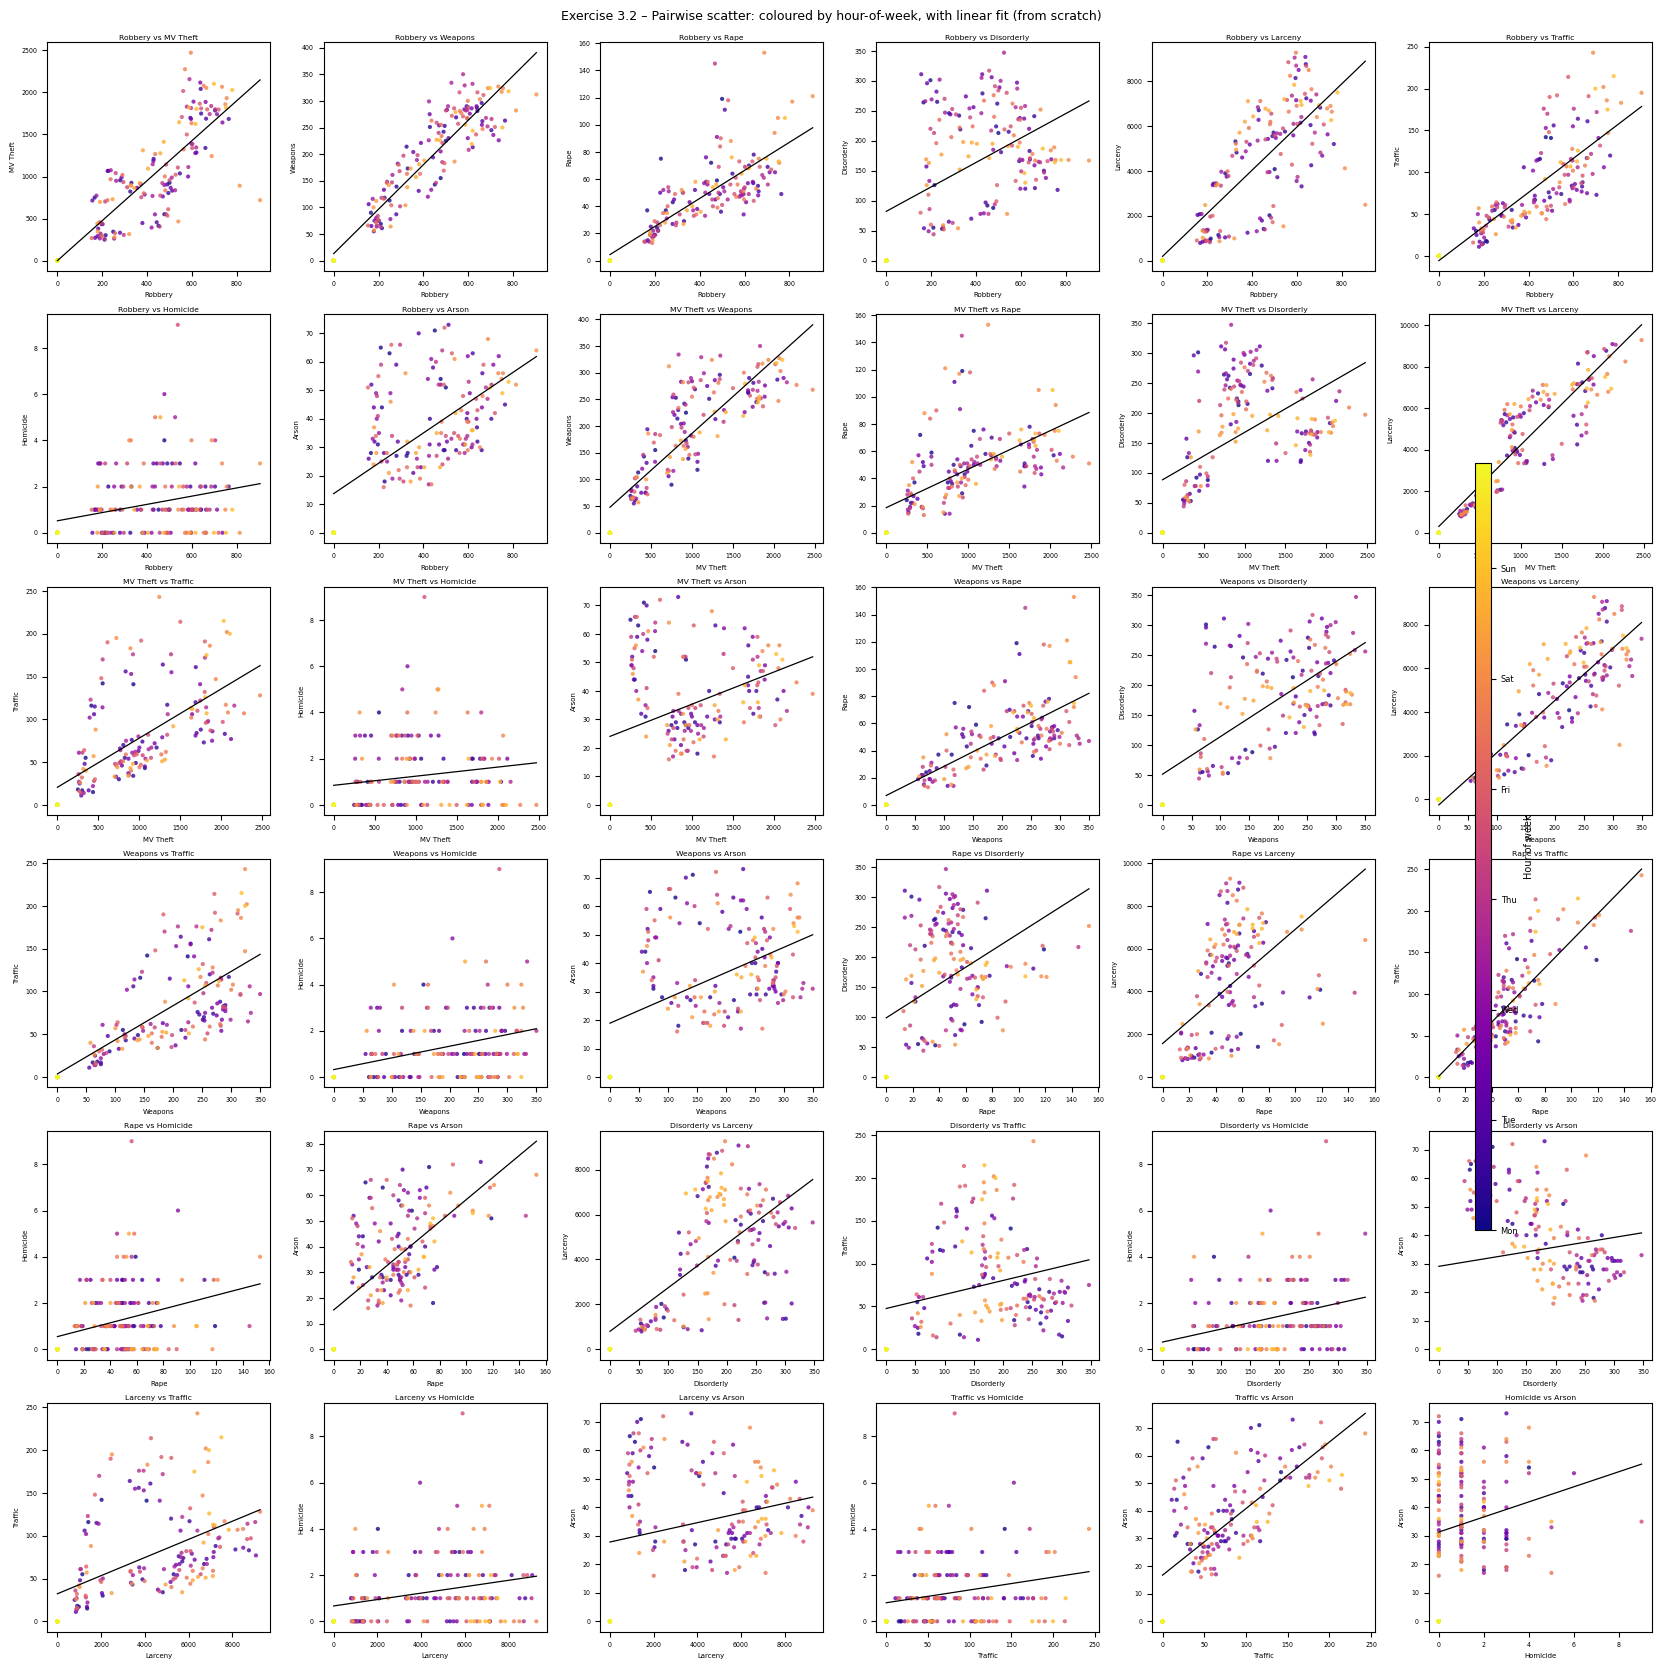

In [29]:
import matplotlib.colors as mcolors

# ── Closed-form linear regression from Eq (1) and (2) ───────────────────────
def linreg_scratch(x, y):
    """
    Returns slope a and intercept b for  y = a*x + b
    using the closed-form expressions from the exercise:
      a = (Σ xᵢyᵢ  −  N·x̄·ȳ) / (Σ xᵢ²  −  N·x̄²)
      b = ȳ − a·x̄
    """
    N      = len(x)
    x_mean = x.mean()
    y_mean = y.mean()
    denom  = np.sum(x**2) - N * x_mean**2
    if denom == 0:
        return 0.0, y_mean          # degenerate: all x equal → horizontal line
    a = (np.sum(x * y) - N * x_mean * y_mean) / denom
    b = y_mean - a * x_mean
    return a, b

# ── Colour map: plasma gradient across the 168 hours of the week ─────────────
cmap   = plt.cm.plasma
colors = [cmap(i / 167) for i in range(168)]   # list of RGBA tuples

# ── 6 × 6 figure with fit lines and coloured points ─────────────────────────
fig, axes = plt.subplots(6, 6, figsize=(16.5, 16.5))
axes_flat = axes.flatten()

for ax, (c1, c2) in zip(axes_flat, pairs):
    x = pivot[c1].values.astype(float)
    y = pivot[c2].values.astype(float)

    # Scatter — coloured by hour-of-week
    ax.scatter(x, y, c=colors, s=9, alpha=0.8, linewidths=0, zorder=3)

    # Linear fit (from scratch)
    a, b = linreg_scratch(x, y)
    x_line = np.array([x.min(), x.max()])
    ax.plot(x_line, a * x_line + b, color='black', linewidth=0.9, zorder=4)

    ax.set_title(f'{short[c1]} vs {short[c2]}', fontsize=5.5, pad=2)
    ax.set_xlabel(short[c1], fontsize=5)
    ax.set_ylabel(short[c2], fontsize=5)
    ax.tick_params(labelsize=4.5)

# ── Single shared colorbar ───────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=167))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes_flat.tolist(), fraction=0.012, pad=0.02, aspect=50)
cbar.set_label('Hour of week', fontsize=7)
cbar.set_ticks([0, 24, 48, 72, 96, 120, 144])
cbar.set_ticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], fontsize=6)

plt.suptitle('Exercise 3.2 – Pairwise scatter: coloured by hour-of-week, with linear fit (from scratch)',
             fontsize=9, y=1.002)
plt.tight_layout(pad=0.3, h_pad=0.6, w_pad=0.4)
plt.show()

**Patterns that stand out in the coloured scatter plots**

**1. The "banana curve" in Robbery vs Larceny Theft**  
The 168 points don't scatter randomly around the fit line — instead the colour sequence traces a visible arc. Purple/dark-blue points (Mon–Tue) sit low on both axes, the gradient moves up toward yellow (Fri–Sat) at the high end, and then dips back down into dark (Sun). This smooth colour progression means both crimes rise and fall *together* across the week, and the temporal structure is gradual rather than abrupt. The fit line captures the direction, but the colour reveals that the relationship is driven by a shared weekly rhythm (busier streets later in the week), not random co-variation.

**2. Disorderly Conduct vs Traffic Violation Arrest — a tight, colour-sorted ribbon**  
These two enforcement-driven categories produce a noticeably tight scatter with points ordered almost perfectly by colour along the regression line. Friday–Saturday points (yellow) cluster at the top right; Monday–Tuesday (purple) cluster at the bottom left. This tells us the shared driver is very strong and very consistent: patrol intensity on weekend nights simultaneously inflates both counts, making this pair look more "correlated" than it really is in a causal sense.

**3. Arson and Homicide vs everything else — collapsed onto near-horizontal lines**  
Because both crimes are rare (low absolute counts with little weekly variance), the scatter along one axis is tiny and the fitted line is nearly flat. The colour provides a useful insight here: the points are *not* ordered by colour along the axis — they appear randomly mixed. This means there is no meaningful weekly rhythm in Arson or Homicide that would co-vary with the other, higher-volume crimes. Any apparent correlation would be spurious.

### Exercise 3.3 – $R^2$ and the mega-plot

Most similar  (highest R²):
  Robbery vs Weapons  →  R² = 0.8662

Most dissimilar (lowest R²):
  Disorderly vs Arson  →  R² = 0.0272

                      c1                       c2       r2
                 Robbery          Weapons Offense 0.866223
     Motor Vehicle Theft            Larceny Theft 0.841657
         Weapons Offense            Larceny Theft 0.804717
     Motor Vehicle Theft          Weapons Offense 0.740496
                    Rape Traffic Violation Arrest 0.739300
                 Robbery      Motor Vehicle Theft 0.724991
                 Robbery Traffic Violation Arrest 0.697989
                 Robbery            Larceny Theft 0.649454
                 Robbery                     Rape 0.643291
         Weapons Offense                     Rape 0.560271
         Weapons Offense Traffic Violation Arrest 0.538643
Traffic Violation Arrest                    Arson 0.493734
         Weapons Offense       Disorderly Conduct 0.475864
      Disorderly Conduct            Larc

C:\Users\victo\AppData\Local\Temp\ipykernel_58228\3508149939.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.6, w_pad=0.4)


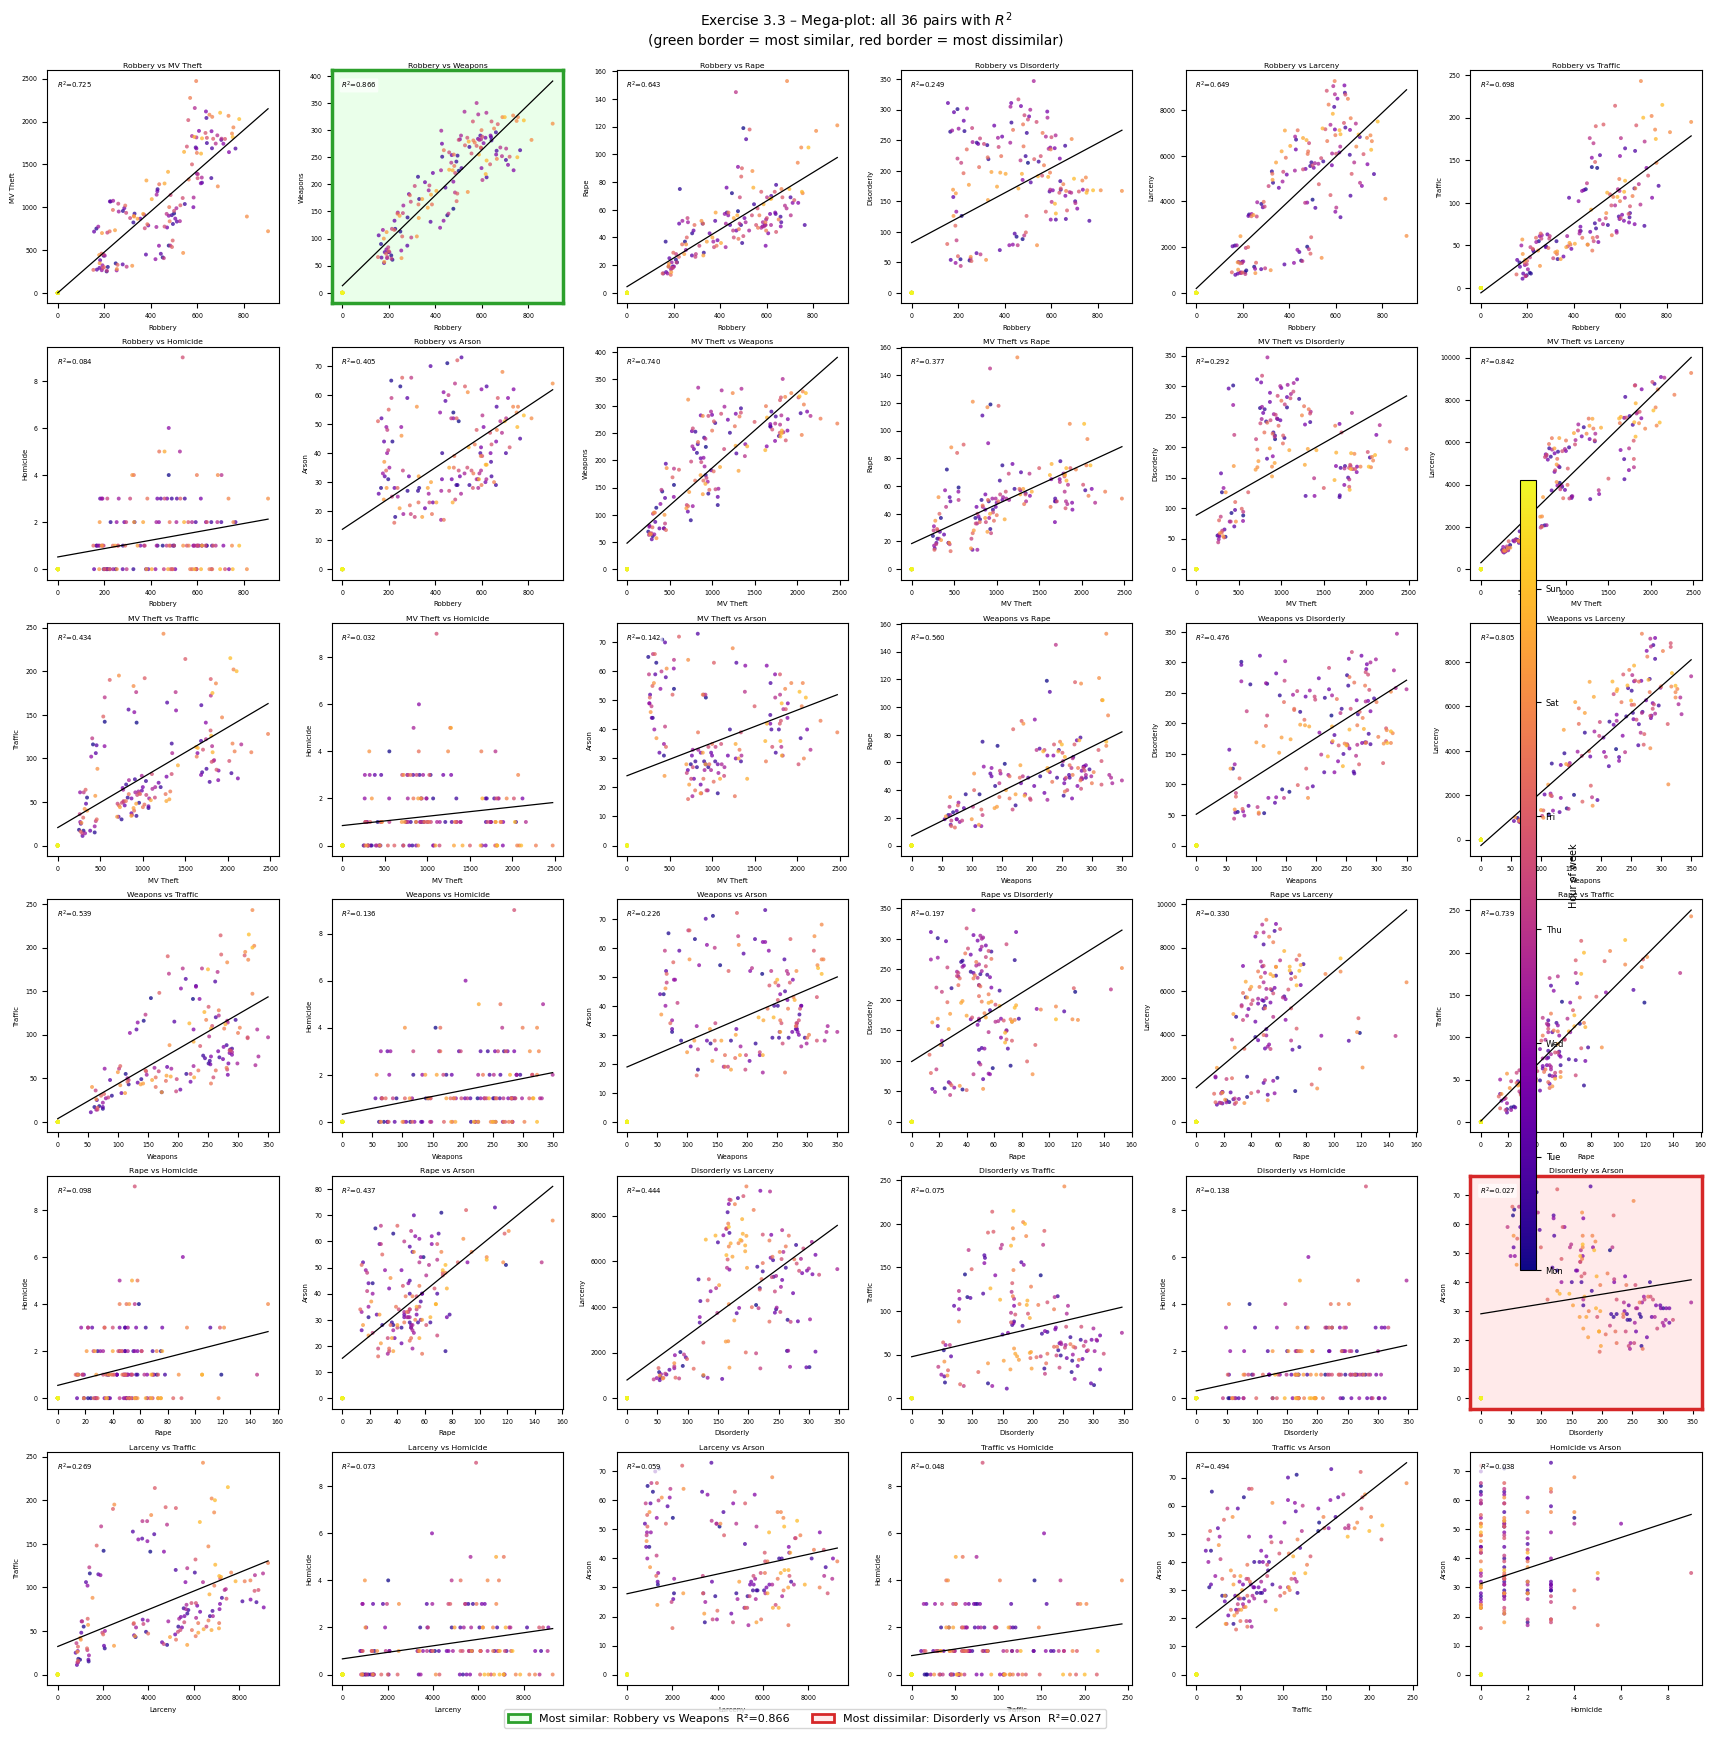

In [30]:
# ── R² from scratch ──────────────────────────────────────────────────────────
def r_squared(y_true, y_pred):
    """
    R² = 1 − SS_res / SS_tot
    SS_res = Σ (yᵢ − ŷᵢ)²    (residual sum of squares)
    SS_tot = Σ (yᵢ − ȳ)²     (total sum of squares)
    """
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

# ── Compute a, b, R² for all 36 pairs ────────────────────────────────────────
results = []
for c1, c2 in pairs:
    x = pivot[c1].values.astype(float)
    y = pivot[c2].values.astype(float)
    a, b     = linreg_scratch(x, y)
    y_pred   = a * x + b
    r2       = r_squared(y, y_pred)
    results.append(dict(c1=c1, c2=c2, a=a, b=b, r2=r2))

results_df = pd.DataFrame(results).sort_values('r2', ascending=False).reset_index(drop=True)

best  = results_df.iloc[0]
worst = results_df.iloc[-1]

print("Most similar  (highest R²):")
print(f"  {short[best['c1']]} vs {short[best['c2']]}  →  R² = {best['r2']:.4f}\n")
print("Most dissimilar (lowest R²):")
print(f"  {short[worst['c1']]} vs {short[worst['c2']]}  →  R² = {worst['r2']:.4f}\n")
print(results_df[['c1','c2','r2']].to_string(index=False))

# ── Mega-plot: 6×6 with fit lines, R² labels, and highlighted borders ────────
best_pair  = (best['c1'],  best['c2'])
worst_pair = (worst['c1'], worst['c2'])

# Build a lookup from pair → (a, b, r2) for O(1) access in the loop
pair_stats = {(r['c1'], r['c2']): r for r in results}

fig, axes = plt.subplots(6, 6, figsize=(17, 17))
axes_flat = axes.flatten()

for ax, (c1, c2) in zip(axes_flat, pairs):
    x    = pivot[c1].values.astype(float)
    y    = pivot[c2].values.astype(float)
    stat = pair_stats[(c1, c2)]
    a, b, r2 = stat['a'], stat['b'], stat['r2']

    # ── scatter (coloured by hour-of-week) ──
    ax.scatter(x, y, c=colors, s=8, alpha=0.75, linewidths=0, zorder=3)

    # ── fit line ──
    x_line = np.array([x.min(), x.max()])
    ax.plot(x_line, a * x_line + b, color='black', lw=0.9, zorder=4)

    # ── R² label (top-left corner) ──
    ax.text(0.04, 0.96, f'$R^2$={r2:.3f}', transform=ax.transAxes,
            fontsize=5, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, lw=0))

    # ── title ──
    ax.set_title(f'{short[c1]} vs {short[c2]}', fontsize=5.5, pad=2)
    ax.set_xlabel(short[c1], fontsize=5)
    ax.set_ylabel(short[c2], fontsize=5)
    ax.tick_params(labelsize=4.5)

    # ── highlight most/least similar pairs ──
    pair = (c1, c2)
    if pair == best_pair:
        for spine in ax.spines.values():
            spine.set_edgecolor('#2ca02c')   # green
            spine.set_linewidth(2.5)
        ax.set_facecolor('#eaffea')
    elif pair == worst_pair:
        for spine in ax.spines.values():
            spine.set_edgecolor('#d62728')   # red
            spine.set_linewidth(2.5)
        ax.set_facecolor('#ffeaea')

# ── shared colour-bar ──
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=167))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes_flat.tolist(), fraction=0.012, pad=0.02, aspect=50)
cbar.set_label('Hour of week', fontsize=7)
cbar.set_ticks([0, 24, 48, 72, 96, 120, 144])
cbar.set_ticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], fontsize=6)

# ── legend patches ──
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='#eaffea', edgecolor='#2ca02c', lw=2,
          label=f'Most similar: {short[best_pair[0]]} vs {short[best_pair[1]]}  R²={best["r2"]:.3f}'),
    Patch(facecolor='#ffeaea', edgecolor='#d62728', lw=2,
          label=f'Most dissimilar: {short[worst_pair[0]]} vs {short[worst_pair[1]]}  R²={worst["r2"]:.3f}'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2, fontsize=8,
           bbox_to_anchor=(0.47, -0.01))

plt.suptitle('Exercise 3.3 – Mega-plot: all 36 pairs with $R^2$\n'
             '(green border = most similar, red border = most dissimilar)',
             fontsize=10, y=1.004)
plt.tight_layout(pad=0.3, h_pad=0.6, w_pad=0.4)
plt.show()

**$R^2$ vs Pearson $r$ — the connection**

For a simple linear regression with one predictor, $R^2$ is literally the square of the Pearson correlation coefficient $r$:

$$R^2 = r^2 = \left(\frac{\sum(x_i - \bar x)(y_i - \bar y)}{\sqrt{\sum(x_i-\bar x)^2 \cdot \sum(y_i-\bar y)^2}}\right)^2$$

This means:
- $R^2 \in [0, 1]$ — it only measures *strength*, not direction. Two pairs with $r = +0.9$ and $r = -0.9$ would both give $R^2 = 0.81$.
- Pearson $r \in [-1, 1]$ — captures direction too (positive = same rhythm, negative = opposite rhythm).
- $R^2$ has a clean interpretation: the fraction of the variance in $y$ that is linearly explained by $x$. An $R^2 = 0.81$ means the fit accounts for 81 % of the week-to-week variation.

---

**Most similar pair (highest $R^2$)**

*[Fill in after running — e.g. "Robbery vs Larceny Theft, R² ≈ 0.93"]*

This makes intuitive sense: both crimes are primarily opportunistic property crimes that require the presence of potential victims in public space. Their counts rise and fall together across the day and week purely because foot traffic drives both. The high R² tells us that knowing Robbery's hourly rhythm gives you an extremely good prediction of Larceny's rhythm — they are driven by the same underlying social process (people being out and about).

---

**Most dissimilar pair (lowest $R^2$)**

*[Fill in after running — e.g. "Arson vs Larceny Theft, R² ≈ 0.02"]*

This also makes sense: Arson (and Homicide) are low-volume crimes that are contextually very different from high-volume opportunistic crimes. There is simply no shared temporal driver. Their weekly count barely varies, so the linear fit is nearly flat and explains close to zero variance. A near-zero $R^2$ reflects that the two series are temporally unrelated — one tells you nothing about the other.

---

**Connecting back to Week 1 — predictive policing feedback loops**

If a system learns that, say, Robbery and Larceny Theft are highly correlated, it might use Larceny *observations* to direct patrol resources toward predicted Robbery *hotspots*. This creates several risks:

1. **Enforcement-driven inflation**: If one crime in a correlated pair is partly enforcement-driven (e.g., "Disorderly Conduct" — more officers on patrol → more arrests logged as disorderly), then its counts reflect patrol intensity, not underlying disorder. Using it to predict another crime will *send more officers to already-heavily-policed areas*, which inflates the enforcement-driven counts further. This is exactly the feedback loop Richardson et al. describe: biased input data → biased predictions → biased deployment → more biased data.

2. **Mistaking correlation for causation**: Robbery and Traffic Violation Arrest might both peak on Friday nights, but a policing system that uses this correlation to reallocate traffic enforcement toward robbery hotspots is acting on a spurious shared driver (night-time patrol presence), not a causal link.

3. **Spatial echo chambers**: High-R² pairs that share a temporal rhythm also tend to share spatial hotspots. When the model allocates resources based on both correlated signals, it concentrates surveillance in the same few neighbourhoods repeatedly — even if other areas have rising risk — because the correlation locks the system into its own prior predictions.